## Melting close to the grounding line, easy calculation
Here we want to calculate the melting close to the grounding line in a semplistic manner by just taking the closest neighbouting (floating) cells 



In [1]:
import numpy as np
import xarray as xr
from matplotlib import pylab as plt
import pandas as pd

In [2]:
pth_model = '/Volumes/Crucial X8/IMSIP6_2300/PIK_PISM'
exp='expAE02_8'
mask_floating='sftflf_AIS_PIK_PISM_expAE02.nc'
draft = 'base_AIS_PIK_PISM_expAE02.nc'
bmb = 'libmassbffl_AIS_PIK_PISM_expAE02.nc'
pth_scalar_values = '/Users/jbec0008/SAEF/ISMIP_2300/ComputedScalars/expAE02/'
smb = 'acabf_AIS_PIK_PISM_expAE02.nc'
bed ='topg_AIS_PIK_PISM_expAE02.nc'


In [3]:
def border_cell_outside_icesheet(mask):

    #### creating boarder cells  around antartic ice mask, e.g. first floating cell or open ocean
    boarder_mask_float = np.zeros(mask.shape)
    difm =mask[1:,:] - mask[:-1,:]
    m_1 = difm ==1
    m_minus1 = difm == -1
    boarder_mask_float[:-1,][m_1]=1
    boarder_mask_float[1:,][m_minus1]=1

    difu = mask[:,1:] - mask[:,:-1]
    m_1u = difu ==1
    m_minus1u = difu == -1
    boarder_mask_float[:,:-1][m_1u]=1
    boarder_mask_float[:,1:][m_minus1u]=1
    return boarder_mask_float

In [4]:
d =xr.open_dataset(pth_model +'/'+exp +'/'+mask_floating)
d_bmb=xr.open_dataset(pth_model +'/'+exp +'/'+bmb)

/Users/jbec0008/python-virtual-environments/vpyplus/lib/python3.9/site-packages/xarray/coding/times.py:710: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


## melting near the grounding line

In [9]:
## create from mask ,onluy1 an 0
# give the closest cell(8km), can be repeated  again yields 16km, ...
ncell = 2 # number of closest cell 
i =0 #time index
# make grouned ice mask:    
m = np.zeros(d.sftflf.values[i,].shape)
m[d.sftflf.values[i,]==0]=1
new_m = m.copy()

total_bmb_ngl =0 # total bmb of floating shelf
for j in range (ncell):


    boarder_mask = border_cell_outside_icesheet(new_m) #get cell next to deifined ice mask
    new_m[boarder_mask==1]=1 # add new cells to ice maksk
    #mask for next cell to ice mask AND floating ice shelf:
    boarder_mask_shelf = (boarder_mask ==1) & (d.sftflf.values[i,]>0) 
    
    # get melting of those cells
    bmb_ngl = d_bmb.libmassbffl.values[i,].copy() #get entire melt rate 
    bmb_ngl[~boarder_mask_shelf] = 0 #set melting outside defined mask 0
    total_bmb_ngl =total_bmb_ngl +np.nansum(bmb_ngl) #add up
    
p_gl =total_bmb_ngl/np.nansum(d_bmb.libmassbffl.values[i,]) 
print( 'melting at gl for the closest ',ncell,'cells',np.round(p_gl*100,2) ,'% of total melting of ice shelves') 

melting at gl for the closest  2 cells 51.66 % of total melting of ice shelves


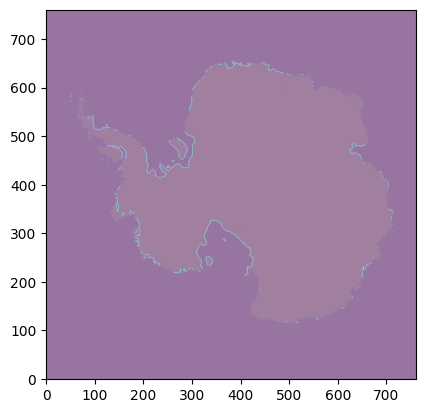

In [10]:
plt.imshow(m,alpha =0.1)

plt.imshow(boarder_mask_shelf.astype('int') ,alpha = 0.5,origin = 'lower')

#TODO:
- get draft close to the groudning line